# Image Calssification using CNN

Dataset used : https://www.kaggle.com/datasets/puneet6060/intel-image-classification/

Frameworks:
- TensorFlow
- Keras
- NumPy
- Matplotlib

## Training

### Importing libraries

In [1]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, InputLayer
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

### Downloading and Preparing Data


In [2]:
!kaggle datasets download -d puneet6060/intel-image-classification

!unzip -q intel-image-classification.zip -d datasets/

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:04<00:00, 76.2MB/s]



In [3]:
# dataset paths
train_dir = 'datasets/seg_train/seg_train'
test_dir = 'datasets/seg_test/seg_test'

batch_size = 32
image_size = (150, 150)

# train and validation datasets
train_ds, validation_ds = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    validation_split=0.2,
    subset="both",
    seed=123,
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=image_size
)


# test dataset
test_ds = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    shuffle=False,
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=image_size
)

# class names
class_names = train_ds.class_names
print("Classes :", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
# normalize image values btw 0 and 1

def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)
test_ds = test_ds.map(process)

In [5]:
# making pipeline faster lil bit
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

### Sample Training Images

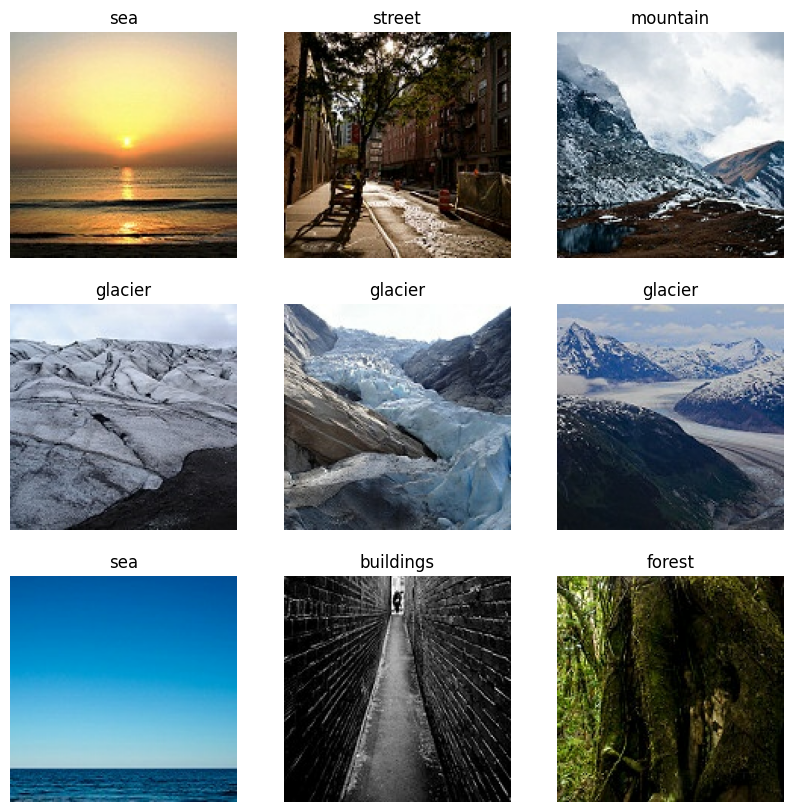

In [6]:
# visualizing some training images

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.show()

### **Observations** : Some classes like glacier and mountain have slight visual similarities, which can make classification slightly challenging for a small CNN.

### CNN Architecture
Keeping architecture simple as instructed

In [7]:
# Simple CNN Model for Multiclass Classification

num_classes = len(class_names)

# cnn model
model = Sequential([
    InputLayer(input_shape=(150, 150, 3)),

    Conv2D(32, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,837,894 (18.46 MB)

 Trainable params: 4,837,446 (18.45 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# stop training if validation loss increases
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Model Training

In [10]:
# model training
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds,
    callbacks=[early_stop]
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - accuracy: 0.4528 - loss: 1.8552 - val_accuracy: 0.4651 - val_loss: 1.4062
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5885 - loss: 1.1599 - val_accuracy: 0.6294 - val_loss: 1.0760
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6671 - loss: 0.9335 - val_accuracy: 0.7124 - val_loss: 0.8600
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7218 - loss: 0.7669 - val_accuracy: 0.7177 - val_loss: 0.7509
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7670 - loss: 0.6602 - val_accuracy: 0.7398 - val_loss: 0.6773
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7910 - loss: 0.5969 - val_accuracy: 0.3311 - val_loss: 7.6650
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8099 - loss: 0.5633 - val_accuracy: 0.7277 - val_loss: 0.7332
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8328 - loss: 0.4831 - 

### **Observations** :
- The model trained smoothly without major instability
- The Validation accuracy is also improved consistently during training which indicates that the model was able to learn meaningful features from the images.

### Model Evaluation

In [11]:
# evaluation on test data
loss, accuracy = model.evaluate(test_ds)

print(f"\nFinal Accuracy : {accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7347 - loss: 0.7142

Final Accuracy : 73.47%


### **Observations** : The model achieved good accuracy even with simplie architecture.


### Training Loss and Accuracy Analysis

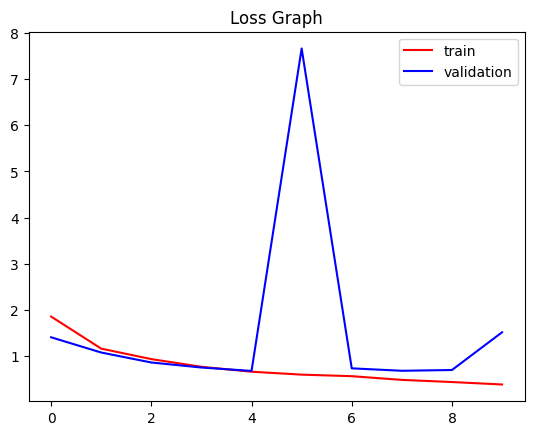

In [12]:
# plotting loss graph

plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.title("Loss Graph")
plt.show()

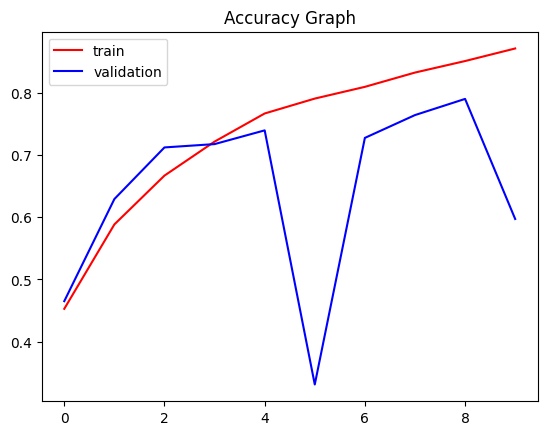

In [13]:
# plotting accuracy graph

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

### **Observations** :
- Both Training and Validation Loss decreased steadily and accuracy remains closer. So, no severe overfitting trend was observed while training

In [14]:
# saving model

model.save('cnn_model.keras')
print("model saved successfully")

model saved successfully


# Prediction Pipeline
Testing the trained CNN model on unseen images

In [15]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

CLASSES = class_names.copy()

In [16]:
#model loading
model = tf.keras.models.load_model(
    "cnn_model.keras",
    compile=False
)

In [17]:
def display_input_image(image_path):
  try:
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()
    return img
  except Exception as e :
    print("An error occured : ", e)
    raise

def preprocess_and_predict(model, image_path):
  img = display_input_image(image_path=image_path)
  # preprocess
  resized_img = img.resize(image_size)  #pre-defined at the start
  img_array = np.array(resized_img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  # prediction
  prediction = model.predict(img_array)
  predicted_class = CLASSES[np.argmax(prediction)]
  confidence = np.max(prediction) * 100

  # results
  print(f"Predicted Class : {predicted_class}")
  print(f"Confidence      : {confidence:.2f}%")

  print("\nPrediction Scores:\n")

  for class_name, score in zip(CLASSES, prediction[0]):
      print(f"{class_name:<12} : {score * 100:.2f}%")

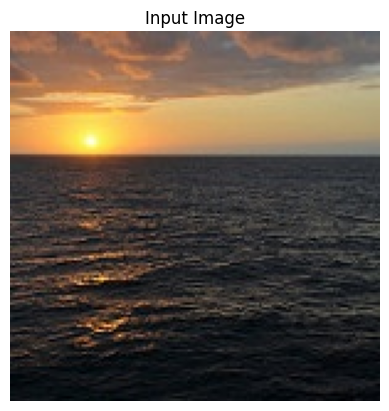

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
Predicted Class : sea
Confidence      : 72.75%

Prediction Scores:

buildings    : 0.18%
forest       : 0.01%
glacier      : 1.89%
mountain     : 25.17%
sea          : 72.75%
street       : 0.01%


In [18]:
IMAGE_PATH = "/content/datasets/seg_pred/seg_pred/10038.jpg"
preprocess_and_predict(model, IMAGE_PATH)

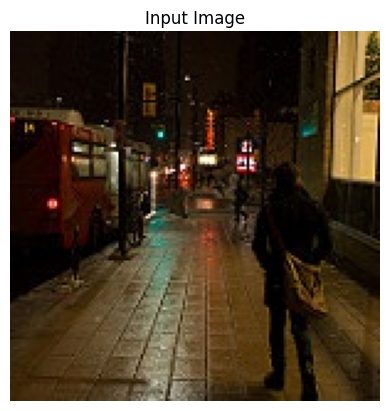

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Class : street
Confidence      : 73.73%

Prediction Scores:

buildings    : 23.71%
forest       : 1.26%
glacier      : 0.55%
mountain     : 0.18%
sea          : 0.58%
street       : 73.73%


In [19]:
IMAGE_PATH = "/content/datasets/seg_pred/seg_pred/656.jpg"
preprocess_and_predict(model, IMAGE_PATH)

### Observations: The model is able to correctly identify most categories, but some visually similar environments may still create occasional confusion on unseen images